In [2]:
!pip install diffusers==0.27.2 transformers==4.38.2 accelerate==0.27.2 huggingface_hub==0.20.3

In [1]:
import torch
import pandas as pd
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from diffusers import AutoencoderKL, DDPMPipeline, DDIMPipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 
import random
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = "dataset"  # change if needed
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [4]:
class TrainDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = str(self.data.iloc[idx]['file_name'])
        label = self.data.iloc[idx]['label']

        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
train_dataset = TrainDataset(
    csv_file=os.path.join(DATA_PATH, "train.csv"),
    root_dir=DATA_PATH,
    transform=transform
)

# IMPORTANT: use subset for speed
train_dataset = torch.utils.data.Subset(train_dataset, range(1000))

In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader = DataLoader(val_data, batch_size=8)

In [7]:
vae1 = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae1.eval()

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [8]:
vae2 = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema").to(device)
vae2.eval()

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [9]:
ddpm = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
unet_ddpm = ddpm.unet.eval()

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 22.74it/s]


In [10]:
ddim = DDIMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
unet_ddim = ddim.unet.eval()

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 69.28it/s]


In [11]:
def extract_vae1(image):
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        latent = vae1.encode(image).latent_dist.sample()
    return latent.flatten().cpu().numpy()

In [12]:
def extract_vae2(image):
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        latent = vae2.encode(image).latent_dist.sample()
    return latent.flatten().cpu().numpy()

In [13]:
def extract_ddpm(image):
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        out = unet_ddpm(image, timestep=10).sample
    return out.flatten().cpu().numpy()

In [14]:
def extract_ddim(image):
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        out = unet_ddim(image, timestep=20).sample
    return out.flatten().cpu().numpy()

In [15]:
def build_features(loader, extractor):
    X, y = [], []
    
    for images, labels in tqdm(loader):
        for i in range(images.size(0)):
            feat = extractor(images[i])
            X.append(feat)
            y.append(labels[i].item())
    
    return np.array(X), np.array(y)

In [25]:
def train_and_eval(name, extractor):
    print(f"\nRunning {name}...")
    
    X_train, y_train = build_features(train_loader, extractor)
    X_val, y_val = build_features(val_loader, extractor)
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    
    preds = clf.predict(X_val)
    probs = clf.predict_proba(X_val)[:, 1]
    
    acc = accuracy_score(y_val, preds)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    # ------------------ CONFUSION MATRIX ------------------
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    # ------------------ ROC CURVE ------------------
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()
    
    # ------------------ SAMPLE PREDICTIONS ------------------
    print("\nSample Predictions:")
    
    indices = random.sample(range(len(val_data)), 5)
    
    plt.figure(figsize=(12, 6))
    
    for i, idx in enumerate(indices):
        image, label = val_data[idx]
        feat = extractor(image)
        pred = clf.predict([feat])[0]
        
        img = image.permute(1, 2, 0).numpy()
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
        
        title = f"P:{'AI' if pred==1 else 'Human'}\nA:{'AI' if label==1 else 'Human'}"
        plt.title(title)
    
    plt.suptitle(f"{name} - Sample Predictions")
    plt.show()
    
    # 🔥 RETURN ALL METRICS (IMPORTANT)
    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": roc_auc
    }


Running VAE1...


100%|██████████| 25/25 [00:08<00:00,  3.01it/s]


Accuracy  : 0.5600
Precision : 0.5938
Recall    : 0.5377
F1 Score  : 0.5644


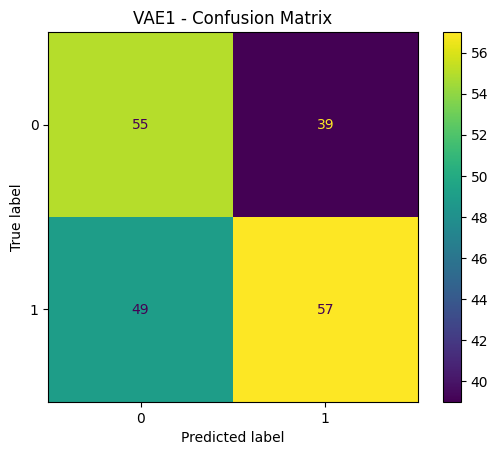

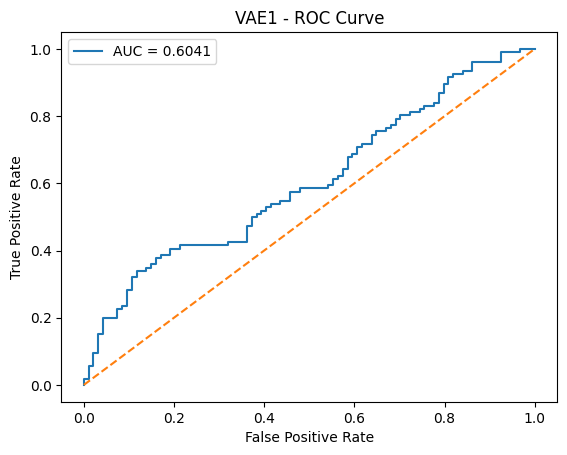


Sample Predictions:


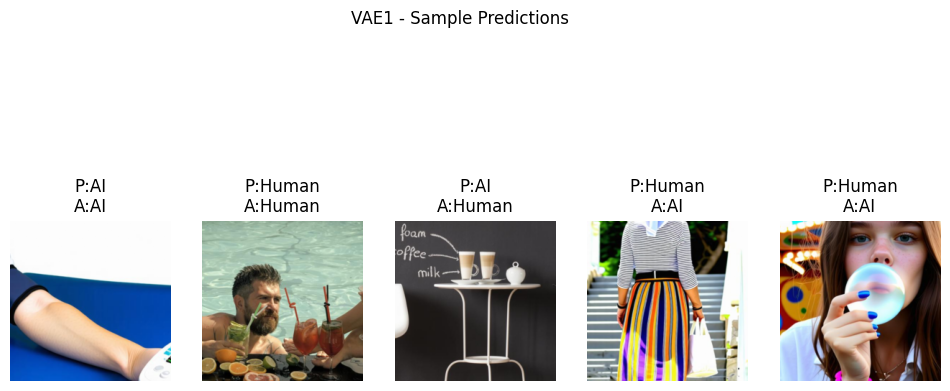


Running VAE2...


100%|██████████| 25/25 [00:07<00:00,  3.25it/s]


Accuracy  : 0.5650
Precision : 0.6022
Recall    : 0.5283
F1 Score  : 0.5628


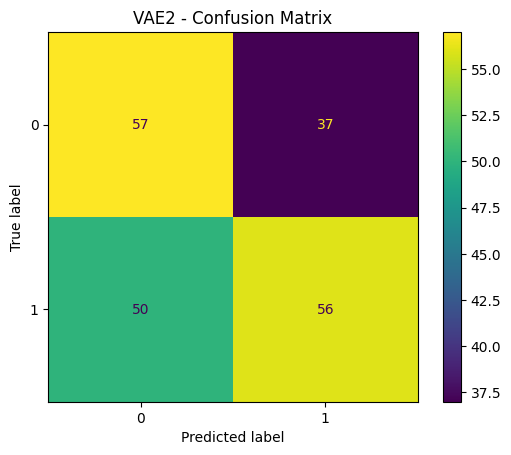

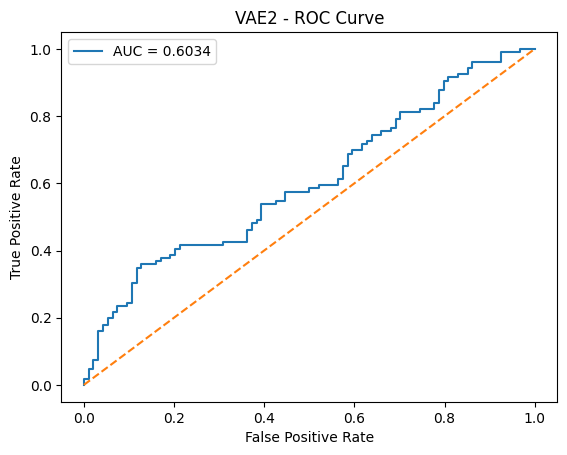


Sample Predictions:


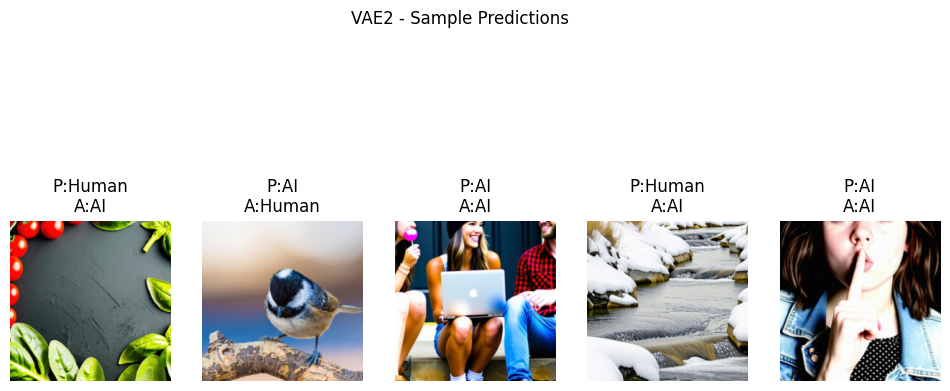


Running DDPM...


100%|██████████| 25/25 [00:17<00:00,  1.43it/s]


Accuracy  : 0.7150
Precision : 0.7059
Recall    : 0.7925
F1 Score  : 0.7467


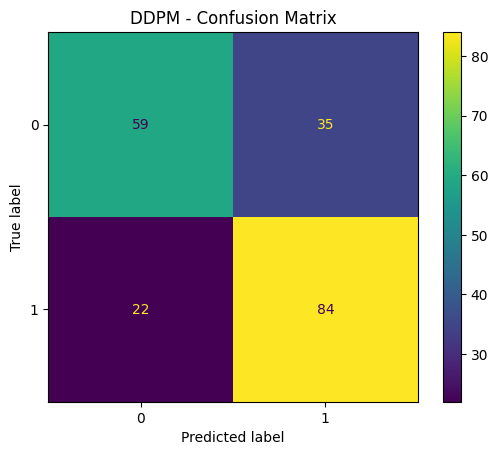

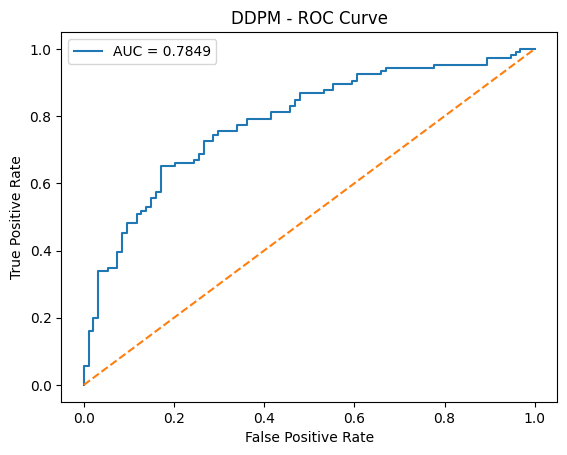


Sample Predictions:


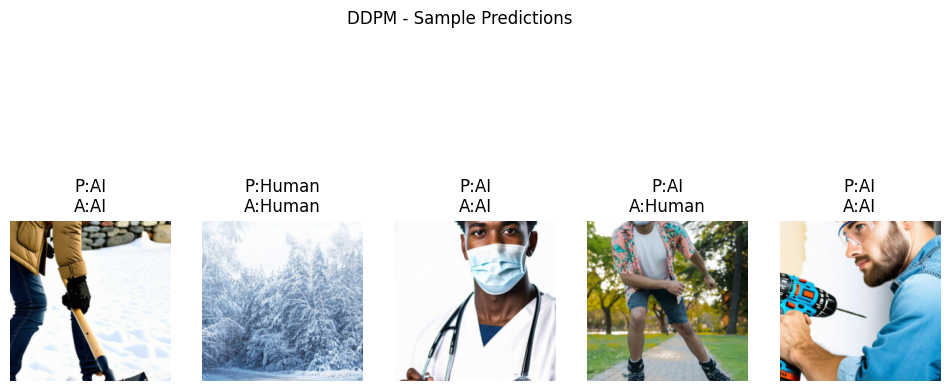


Running DDIM...


100%|██████████| 25/25 [00:17<00:00,  1.43it/s]


Accuracy  : 0.7450
Precision : 0.7434
Recall    : 0.7925
F1 Score  : 0.7671


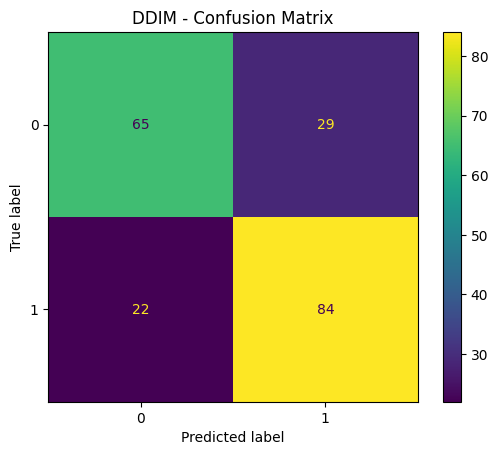

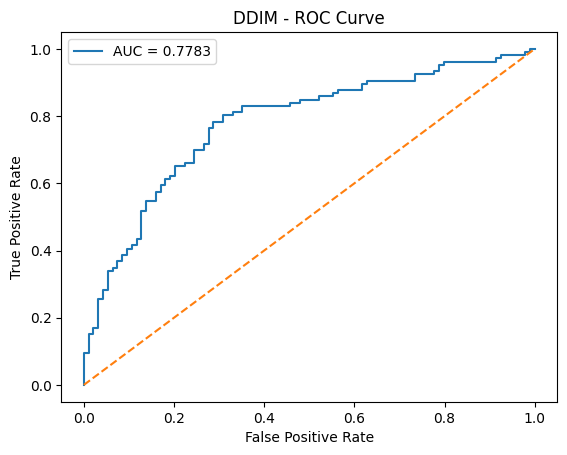


Sample Predictions:


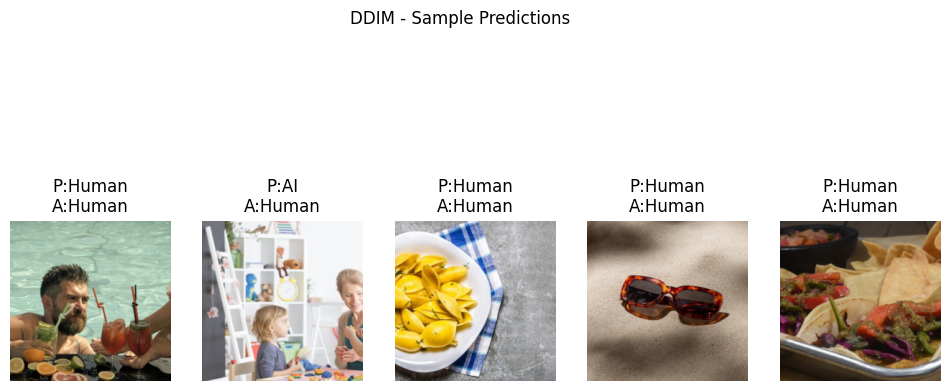

In [26]:
results = {}

results["VAE (SD)"] = train_and_eval("VAE1", extract_vae1)
results["VAE (Tiny)"] = train_and_eval("VAE2", extract_vae2)
results["DDPM"] = train_and_eval("DDPM", extract_ddpm)
results["DDIM"] = train_and_eval("DDIM", extract_ddim)

In [27]:
import pandas as pd

df = pd.DataFrame(results).T  # transpose for readability
print("\nFinal Comparison Table:\n")
print(df)


Final Comparison Table:

            Accuracy  Precision    Recall  F1 Score       AUC
VAE (SD)       0.560   0.593750  0.537736  0.564356  0.604075
VAE (Tiny)     0.565   0.602151  0.528302  0.562814  0.603372
DDPM           0.715   0.705882  0.792453  0.746667  0.784926
DDIM           0.745   0.743363  0.792453  0.767123  0.778302


In [28]:
best_model = df["F1 Score"].idxmax()
best_score = df["F1 Score"].max()

print("\nBest Model:")
print(f"{best_model} with F1 Score = {best_score:.4f}")


Best Model:
DDIM with F1 Score = 0.7671


In [29]:
df_sorted = df.sort_values(by="F1 Score", ascending=False)

print("\nSorted Comparison Table:\n")
print(df_sorted)


Sorted Comparison Table:

            Accuracy  Precision    Recall  F1 Score       AUC
DDIM           0.745   0.743363  0.792453  0.767123  0.778302
DDPM           0.715   0.705882  0.792453  0.746667  0.784926
VAE (SD)       0.560   0.593750  0.537736  0.564356  0.604075
VAE (Tiny)     0.565   0.602151  0.528302  0.562814  0.603372


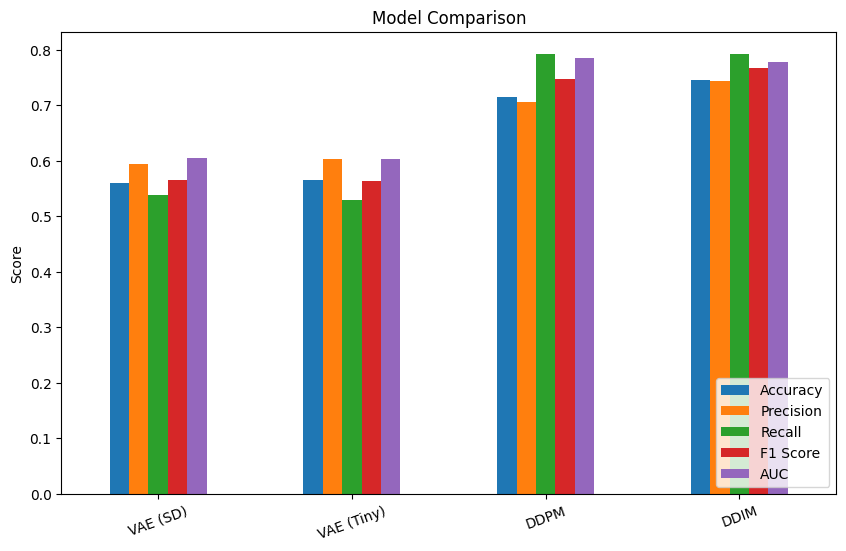

In [30]:
import matplotlib.pyplot as plt

df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()